Computing scans (this may take several minutes)...

  → Werner
     param=1.000  dim(S)=4  cost=2.0000e+005

  → Isotropic
     param=1.000  dim(S)=4  cost=2.0000e+005

  → Bell Mixture
     param=1.000  dim(S)=4  cost=2.0000e+005

All scans done. Plotting...


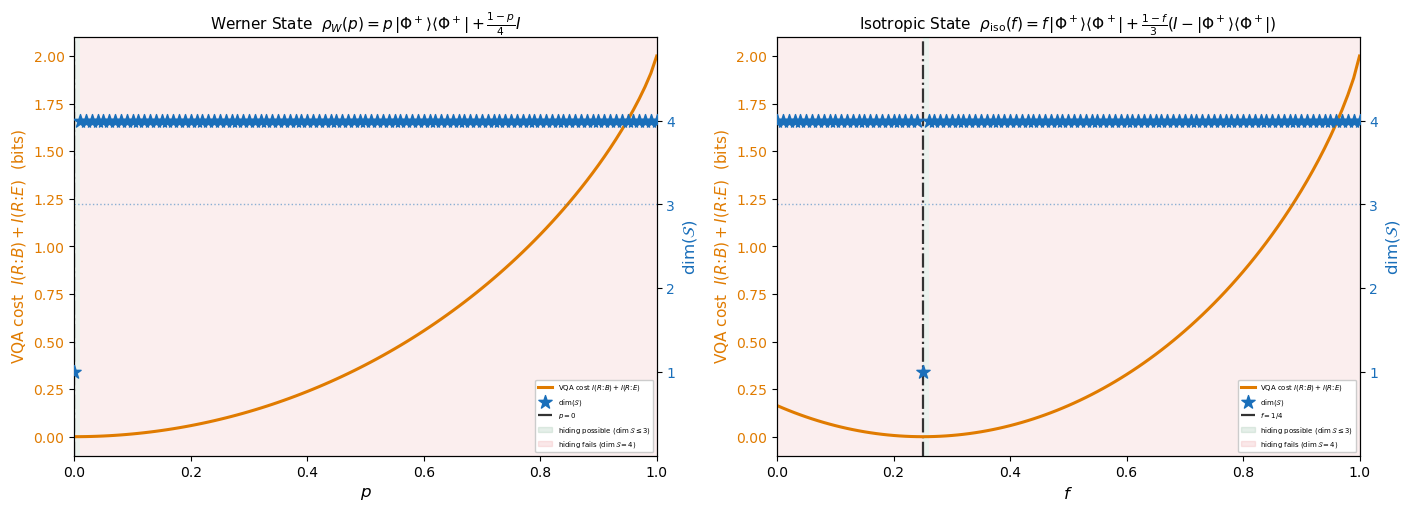

Saved: fig1_werner_isotropic.pdf / .png


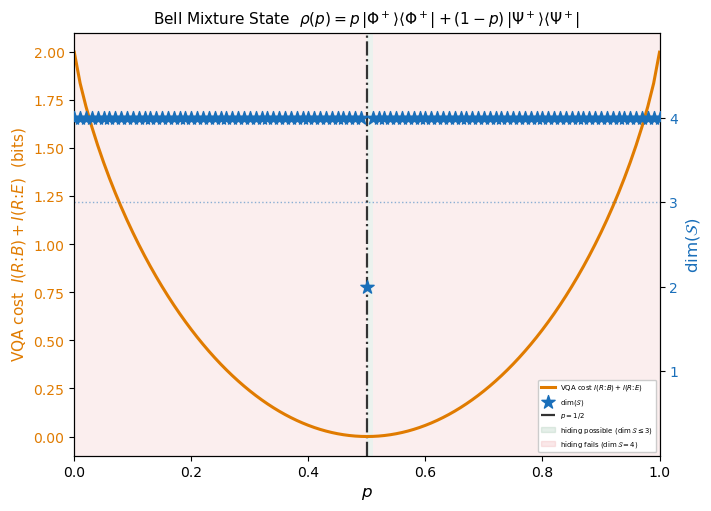

Saved: fig2_bell_mixture.pdf / .png


In [1]:
# ============================================================
# OPERATOR SUBSPACE EVOLUTION PLOTS — fully self-contained
# Figure 1: Werner + Isotropic (1x2)
# Figure 2: Bell Mixture
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import expm

# ============================================================
# PRIMITIVES
# ============================================================

def partial_trace_out(rho, keep, dims):
    dims  = list(dims)
    n     = len(dims)
    rho_t = rho.reshape(dims + dims)
    trace_out = [i for i in range(n) if i not in keep]
    for ax in sorted(trace_out, reverse=True):
        current_n = rho_t.ndim // 2
        rho_t = np.trace(rho_t, axis1=ax, axis2=ax + current_n)
    kept_dims = [dims[i] for i in keep]
    d_keep    = int(np.prod(kept_dims))
    return rho_t.reshape(d_keep, d_keep)

def von_neumann_entropy(rho):
    eigvals = np.linalg.eigvalsh(rho).real
    eigvals = eigvals[eigvals > 1e-12]
    return float(-np.sum(eigvals * np.log2(eigvals)))

def mutual_information(rho_AB, rho_A, rho_B):
    return (von_neumann_entropy(rho_A)
          + von_neumann_entropy(rho_B)
          - von_neumann_entropy(rho_AB))

# ============================================================
# PAULI MATRICES
# ============================================================

_I2 = np.eye(2, dtype=complex)
_X  = np.array([[0, 1],  [1,  0]],  dtype=complex)
_Y  = np.array([[0,-1j], [1j, 0]],  dtype=complex)
_Z  = np.array([[1, 0],  [0, -1]],  dtype=complex)
_PAULI_BASIS = [_I2, _X, _Y, _Z]

# ============================================================
# OPERATOR SUBSPACE DIMENSION
# ============================================================

def _pauli_coeffs(M):
    return np.array([0.5 * np.real(np.trace(s @ M)) for s in _PAULI_BASIS])

def compute_dim_S(rho_RA, tol=1e-10):
    A   = rho_RA[:2, :2]
    D   = rho_RA[2:, 2:]
    B   = rho_RA[:2, 2:]
    ReB = 0.5  * (B + B.conj().T)
    ImB = 0.5j * (B.conj().T - B)
    C   = np.array([_pauli_coeffs(A),
                    _pauli_coeffs(D),
                    _pauli_coeffs(ReB),
                    _pauli_coeffs(ImB)], dtype=float)
    sv    = np.linalg.svd(C, compute_uv=False)
    dim_S = int(np.sum(sv > tol))
    return dim_S

# ============================================================
# KAK / U(4) BUILDER
# ============================================================

def su2(alpha, beta, gamma):
    def Rz(t): return np.array([[np.exp(-0.5j*t), 0],
                                [0, np.exp( 0.5j*t)]], dtype=complex)
    def Ry(t):
        c, s = np.cos(t/2), np.sin(t/2)
        return np.array([[c,-s],[s, c]], dtype=complex)
    return Rz(alpha) @ Ry(beta) @ Rz(gamma)

def build_u4(params):
    A1 = su2(*params[0:3]);  A2 = su2(*params[3:6])
    A3 = su2(*params[6:9]);  A4 = su2(*params[9:12])
    c1, c2, c3 = params[12], params[13], params[14]
    phi = params[15]
    XX  = np.kron(_X, _X);  YY = np.kron(_Y, _Y);  ZZ = np.kron(_Z, _Z)
    interaction = expm(1j * (c1*XX + c2*YY + c3*ZZ))
    U = np.kron(A1, A2) @ interaction @ np.kron(A3, A4)
    return U * np.exp(1j * phi)

# ============================================================
# COST FUNCTION  I(R:B) + I(R:E)
# ============================================================

def cost_function(params, rho_RA):
    U         = build_u4(params)
    rho_RAE   = np.kron(rho_RA, np.array([[1,0],[0,0]], dtype=complex))
    U_full    = np.kron(np.eye(2, dtype=complex), U)
    sigma_RBE = U_full @ rho_RAE @ U_full.conj().T
    dims      = [2, 2, 2]
    sigma_R   = partial_trace_out(sigma_RBE, keep=[0],    dims=dims)
    sigma_B   = partial_trace_out(sigma_RBE, keep=[1],    dims=dims)
    sigma_E   = partial_trace_out(sigma_RBE, keep=[2],    dims=dims)
    sigma_RB  = partial_trace_out(sigma_RBE, keep=[0, 1], dims=dims)
    sigma_RE  = partial_trace_out(sigma_RBE, keep=[0, 2], dims=dims)
    I_RB = mutual_information(sigma_RB, sigma_R, sigma_B)
    I_RE = mutual_information(sigma_RE, sigma_R, sigma_E)
    return I_RB + I_RE

def vqa_cost_scan(rho_RA, n_restarts=15):
    best = float('inf')
    for _ in range(n_restarts):
        x0     = np.random.uniform(-np.pi, np.pi, 16)
        result = minimize(cost_function, x0, args=(rho_RA,),
                          method='L-BFGS-B',
                          bounds=[(-np.pi, np.pi)] * 16,
                          options={'maxiter': 3000, 'ftol': 1e-13, 'gtol': 1e-9})
        if result.fun < best:
            best = result.fun
    return best

# ============================================================
# STATE FAMILIES
# ============================================================

def werner_state(p):
    phi_plus = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
    dm_phi   = np.outer(phi_plus, phi_plus.conj())
    return p * dm_phi + (1 - p) / 4 * np.eye(4, dtype=complex)

def isotropic_state(f):
    phi_plus = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
    dm_phi   = np.outer(phi_plus, phi_plus.conj())
    return f * dm_phi + (1 - f) / 3 * (np.eye(4, dtype=complex) - dm_phi)

def bell_mixture_state(p):
    phi_plus = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
    psi_plus = np.array([0, 1, 1, 0], dtype=complex) / np.sqrt(2)
    dm_phi   = np.outer(phi_plus, phi_plus.conj())
    dm_psi   = np.outer(psi_plus, psi_plus.conj())
    return p * dm_phi + (1 - p) * dm_psi

# ============================================================
# SCAN PARAMETERS  —  tune these as needed
# ============================================================

N_POINTS   = 101
N_RESTARTS = 15
TOL_RANK   = 1e-10

state_specs = [
    {
        "name":         "Werner",
        "title":        r"Werner State  $\rho_W(p)=p\,|\Phi^+\rangle\langle\Phi^+|+\frac{1-p}{4}I$",
        "param_label":  r"$p$",
        "params":       np.linspace(0, 1, N_POINTS),
        "state_fn":     werner_state,
        "hiding_param": 0.0,
        "vline_label":  r"$p=0$",
    },
    {
        "name":         "Isotropic",
        "title":        r"Isotropic State  $\rho_{\rm iso}(f)=f\,|\Phi^+\rangle\langle\Phi^+|+\frac{1-f}{3}(I-|\Phi^+\rangle\langle\Phi^+|)$",
        "param_label":  r"$f$",
        "params":       np.linspace(0, 1, N_POINTS),
        "state_fn":     isotropic_state,
        "hiding_param": 1/4,
        "vline_label":  r"$f=1/4$",
    },
    {
        "name":         "Bell Mixture",
        "title":        r"Bell Mixture State  $\rho(p)=p\,|\Phi^+\rangle\langle\Phi^+|+(1-p)\,|\Psi^+\rangle\langle\Psi^+|$",
        "param_label":  r"$p$",
        "params":       np.linspace(0, 1, N_POINTS),
        "state_fn":     bell_mixture_state,
        "hiding_param": 0.5,
        "vline_label":  r"$p=1/2$",
    },
]

# ============================================================
# COMPUTE  dim(S) and VQA cost for all three families
# ============================================================

print("Computing scans (this may take several minutes)...")

results = []
for spec in state_specs:
    print(f"\n  → {spec['name']}")
    dims_S, costs = [], []
    for i, p in enumerate(spec["params"]):
        rho   = spec["state_fn"](p)
        dim_S = compute_dim_S(rho, tol=TOL_RANK)
        cost  = vqa_cost_scan(rho, n_restarts=N_RESTARTS)
        dims_S.append(dim_S)
        costs.append(cost)
        print(f"     param={p:.3f}  dim(S)={dim_S}  cost={cost:.4e}", end="\r")
    results.append({
        "dims_S": np.array(dims_S),
        "costs":  np.array(costs),
    })
    print()

print("\nAll scans done. Plotting...")

# ============================================================
# SHARED PLOT HELPER
# ============================================================

COST_COLOR  = "#e07b00"   # orange
DIMS_COLOR  = "#1a6fba"   # blue
VLINE_COLOR = "#333333"
HIDE_GREEN  = "#096528"
HIDE_RED    = "#d62728"

def plot_panel(ax, spec, res):
    params = spec["params"]
    dims_S = res["dims_S"]
    costs  = res["costs"]
    hp     = spec["hiding_param"]

    # ── Background shading ────────────────────────────────────────
    for i in range(len(params) - 1):
        color = HIDE_GREEN if dims_S[i] <= 3 else HIDE_RED
        ax.axvspan(params[i], params[i+1],
                   alpha=0.08, color=color, linewidth=0)

    # ── VQA cost (left axis, solid line) ─────────────────────────
    h_cost, = ax.plot(params, costs,
                      color=COST_COLOR, linewidth=2.2, linestyle="-",
                      label=r"VQA cost $I(R\!:\!B)+I(R\!:\!E)$", zorder=3)

    # ── Vertical line at perfect-hiding parameter ─────────────────
    ax.axvline(hp, color=VLINE_COLOR, linewidth=1.6,
               linestyle="-.", zorder=2, label=spec["vline_label"])

    ax.set_xlabel(spec["param_label"], fontsize=12)
    ax.set_ylabel(r"VQA cost  $I(R\!:\!B)+I(R\!:\!E)$  (bits)",
                  fontsize=11, color=COST_COLOR)
    ax.tick_params(axis='y', labelcolor=COST_COLOR)
    ax.set_xlim(params[0], params[-1])
    ax.set_title(spec["title"], fontsize=11, pad=6)

    # ── dim(S) stars (right axis) ─────────────────────────────────
    ax2 = ax.twinx()
    h_dim = ax2.scatter(params, dims_S,
                        marker="*", s=100, color=DIMS_COLOR,
                        zorder=5, label=r"$\dim(\mathcal{S})$")
    ax2.axhline(3, color=DIMS_COLOR, linewidth=1.0,
                linestyle=":", alpha=0.5)
    ax2.set_ylim(0, 5)
    ax2.set_yticks([1, 2, 3, 4])
    ax2.set_ylabel(r"$\dim(\mathcal{S})$", fontsize=12, color=DIMS_COLOR)
    ax2.tick_params(axis='y', labelcolor=DIMS_COLOR)

    # ── Legend: cost + dim(S) + vline + shading ───────────────────
    from matplotlib.lines import Line2D
    import matplotlib.patches as mpatches
    h_vline  = Line2D([0],[0], color=VLINE_COLOR, linewidth=1.6,
                      linestyle="-.", label=spec["vline_label"])
    h_green  = mpatches.Patch(color=HIDE_GREEN, alpha=0.1,
                               label=r"hiding possible ($\dim\mathcal{S}\leq 3$)")
    h_red    = mpatches.Patch(color=HIDE_RED,   alpha=0.1,
                               label=r"hiding fails ($\dim\mathcal{S}=4$)")
    ax.legend(handles=[h_cost, h_dim, h_vline, h_green, h_red],
              fontsize=5, loc="lower right",
              framealpha=1.0, ncol=1)

    return ax, ax2

# ============================================================
# FIGURE 1:  Werner (left) + Isotropic (right)
# ============================================================

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, spec, res in zip(axes1, state_specs[:2], results[:2]):
    plot_panel(ax, spec, res)

#fig1.suptitle(
#    r"Operator Subspace Evolution: $\dim(\mathcal{S})$ and VQA Cost",
#    fontsize=13, fontweight="bold")

fig1.savefig("fig1_werner_isotropic.pdf", bbox_inches="tight", dpi=200)
fig1.savefig("fig1_werner_isotropic.png", bbox_inches="tight", dpi=200)
plt.show()
print("Saved: fig1_werner_isotropic.pdf / .png")

# ============================================================
# FIGURE 2:  Bell Mixture
# ============================================================

fig2, ax2_single = plt.subplots(1, 1, figsize=(7, 5), constrained_layout=True)

plot_panel(ax2_single, state_specs[2], results[2])

#fig2.suptitle(
 #   r"Operator Subspace Evolution: $\dim(\mathcal{S})$ and VQA Cost",
   # fontsize=13, fontweight="bold")

fig2.savefig("fig2_bell_mixture.pdf", bbox_inches="tight", dpi=200)
fig2.savefig("fig2_bell_mixture.png", bbox_inches="tight", dpi=200)
plt.show()
print("Saved: fig2_bell_mixture.pdf / .png")